# EDA

Synthetic Berlin S-Bahn trips. The question for later modeling is whether a trip is delayed, using only what would already be known on the platform. Cancelled trips are dropped. Full column lists are in `docs/data_quality.md`. Leakage rules are in `docs/feature_dictionary.md`.

In [2]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path.home() / (
    ".cache/kagglehub/datasets/alperenmyung/"
    "berlin-s-bahn-punctuality-database/versions/2/berlin_sbahn_delays.db"
)

PRESUMED_KEYS = {
    "city_events": "event_name",
    "incidents": "incident_id",
    "lines": "line_id",
    "stations": "station_id",
    "strikes": "strike_start",
    "trips": "trip_id",
    "weather": "timestamp",
}

with sqlite3.connect(DB_PATH) as con:
    table_names = [
        row[0]
        for row in con.execute(
            """
            SELECT name FROM sqlite_master
            WHERE type = 'table' AND name NOT LIKE 'sqlite_%'
            ORDER BY name
            """
        )
    ]
    tables = {
        name: pd.read_sql_query(f'SELECT * FROM "{name}"', con) for name in table_names
    }

all_trips = tables["trips"].copy()
all_trips["scheduled_departure_time"] = pd.to_datetime(all_trips["scheduled_departure_time"])
trips = all_trips.loc[all_trips["is_cancelled"] == 0].copy()
trips.shape

(130911, 9)

In [4]:
tables["lines"].head(10)

,line_id,line_name,is_ring_line,delay_propensity
0,S1,S1,0,0.70
1,S2,S2,0,0.60
2,S5,S5,0,0.80
3,S7,S7,0,0.85
4,S41,S41 (Ring),1,1.00
5,S42,S42 (Ring),1,1.00


In [5]:
tables["trips"].head(10)

,trip_id,line_id,start_station_id,end_station_id,scheduled_departure_time,is_peak_hour,is_delayed,delay_minutes,is_cancelled
0,0,S42,S1,S6,2024-08-16 02:31:00,0,0,1,0
1,1,S2,S4,S7,2024-02-02 18:31:00,1,0,2,0
2,2,S42,S3,S5,2024-10-11 00:03:00,0,0,1,0
3,3,S1,S5,S7,2024-08-20 02:04:00,0,0,1,0
4,4,S7,S5,S6,2024-05-26 03:54:00,0,0,0,0
5,5,S2,S8,S6,2024-08-26 21:15:00,0,0,1,0
6,6,S41,S6,S3,2024-06-06 07:19:00,1,0,3,0
7,7,S2,S2,S7,2024-07-23 22:25:00,0,0,1,0
8,8,S2,S10,S3,2024-07-10 23:56:00,0,0,1,0
9,9,S2,S6,S8,2024-12-21 10:01:00,0,0,1,0


In [6]:
tables["stations"].head(10)

,station_id,name,is_major_hub,location_category
0,S1,Berlin Hauptbahnhof,1,city_center
1,S2,Berlin Ostkreuz,1,city_center
2,S3,Potsdam Hauptbahnhof,0,suburb
3,S4,Friedrichstraße,1,city_center
4,S5,Olympiastadion,0,event_venue
5,S6,Flughafen BER,0,airport
6,S7,Alexanderplatz,1,city_center
7,S8,Charlottenburg,1,city_center
8,S9,Berlin Südkreuz,1,city_center
9,S10,Berlin-Spandau,0,suburb


## Target definition

`is_delayed` is 1 only when `delay_minutes` is 6 or more. Minutes 0–5 are the same on-time class.

In [3]:
band = np.where(trips["delay_minutes"] <= 5, "0-5 min", "6+ min")
pd.crosstab(band, trips["is_delayed"], rownames=["delay_minutes"], colnames=["is_delayed"])

is_delayed,0,1
delay_minutes,,
0-5 min,126968,0
6+ min,0,3943


## Class balance

Cancelled trips sit in both classes (65 on time, 795 delayed), so all 860 are dropped. Of the remaining 130,911 trips, 126,968 (96.99%) are on time and 3,943 (3.01%) are delayed. Accuracy alone will look strong for a model that always predicts on time.

cancelled by is_delayed
is_delayed
0     65
1    795
Name: count, dtype: int64


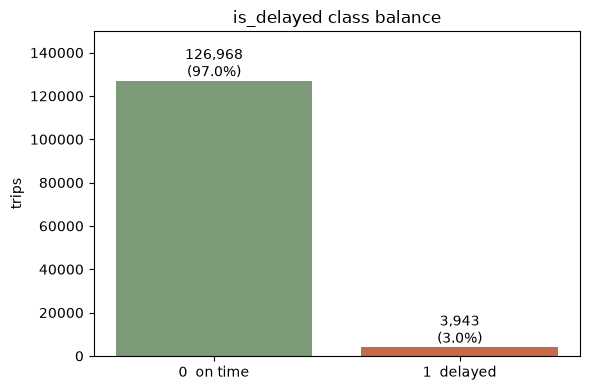

In [4]:
cancelled = all_trips.loc[all_trips["is_cancelled"] == 1, "is_delayed"]
print("cancelled by is_delayed")
print(cancelled.value_counts().sort_index())

balance = trips["is_delayed"].value_counts().sort_index()
labels = ["0  on time", "1  delayed"]
total = int(balance.sum())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, balance.to_numpy(), color=["#7d9a78", "#c46b4a"])
for bar, count in zip(bars, balance.to_numpy()):
    pct = 100 * count / total
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
    )
ax.set_ylabel("trips")
ax.set_title("is_delayed class balance")
ax.set_ylim(0, balance.max() * 1.18)
fig.tight_layout()
plt.show()

## Delay distribution

The histogram uses `log1p(delay_minutes)`, so a delay of 0 stays on the axis. The dashed line at 5 minutes marks the on-time band. Trip counts use a log scale so the long tail stays visible.

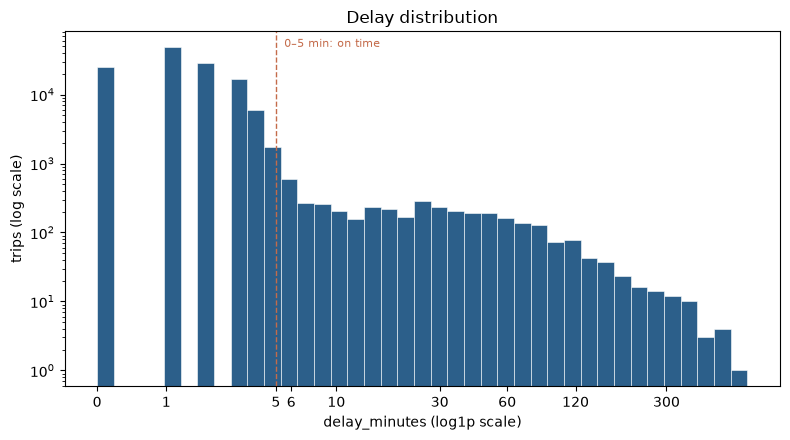

In [5]:
logged = np.log1p(trips["delay_minutes"])
bins = np.linspace(0, logged.max(), 40)
tick_minutes = [0, 1, 5, 6, 10, 30, 60, 120, 300, 1000]
tick_minutes = [minute for minute in tick_minutes if minute <= trips["delay_minutes"].max()]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(logged, bins=bins, color="#2c5f8a", edgecolor="white", linewidth=0.4)
ax.set_yscale("log")
ax.set_xticks(np.log1p(tick_minutes))
ax.set_xticklabels([str(minute) for minute in tick_minutes])
ax.axvline(np.log1p(5), color="#c46b4a", linestyle="--", linewidth=1)
ax.set_xlabel("delay_minutes (log1p scale)")
ax.set_ylabel("trips (log scale)")
ax.set_title("Delay distribution")
ax.annotate(
    "0–5 min: on time",
    xy=(np.log1p(5), 0.98),
    xycoords=("data", "axes fraction"),
    xytext=(6, 0),
    textcoords="offset points",
    va="top",
    fontsize=8,
    color="#c46b4a",
)
fig.tight_layout()
plt.show()

## Table health

Every column is 0% null. No table has an exact duplicate row. Each presumed key is unique, and no trip `line_id` or station id is missing from `lines` or `stations`. Every column is listed in `docs/data_quality.md`.

In [6]:
rows = []
for name, frame in tables.items():
    key = PRESUMED_KEYS[name]
    rows.append(
        {
            "table": name,
            "rows": len(frame),
            "duplicate_rows": int(frame.duplicated().sum()),
            "presumed_key": key,
            "key_unique": bool(frame[key].is_unique),
            "max_null_pct": float(frame.isna().mean().max() * 100),
        }
    )
summary = pd.DataFrame(rows)

line_ids = set(tables["lines"]["line_id"])
station_ids = set(tables["stations"]["station_id"])
orphans = pd.Series(
    {
        "line_id": int((~all_trips["line_id"].isin(line_ids)).sum()),
        "start_station_id": int((~all_trips["start_station_id"].isin(station_ids)).sum()),
        "end_station_id": int((~all_trips["end_station_id"].isin(station_ids)).sum()),
    },
    name="orphan_rows",
)
display(summary)
orphans

,table,rows,duplicate_rows,presumed_key,key_unique,max_null_pct
0,city_events,3,0,event_name,True,0.0
1,incidents,36,0,incident_id,True,0.0
2,lines,6,0,line_id,True,0.0
3,stations,10,0,station_id,True,0.0
4,strikes,3,0,strike_start,True,0.0
5,trips,131771,0,trip_id,True,0.0
6,weather,8761,0,timestamp,True,0.0


line_id             0
start_station_id    0
end_station_id      0
Name: orphan_rows, dtype: int64

## Calendar

Trips run from 2024-01-01 through 2024-12-30, on 365 dates. 2024-12-31 has no trips. All 36 incidents, 3 city events, and 3 strikes fall inside that calendar. The exact dates are in `docs/data_quality.md`.

In [7]:
departure = all_trips["scheduled_departure_time"]
start, end = departure.min(), departure.max()
trip_days = departure.dt.date.nunique()

incident_time = pd.to_datetime(tables["incidents"]["timestamp"])
event_day = pd.to_datetime(tables["city_events"]["date"])
strike_start = pd.to_datetime(tables["strikes"]["strike_start"])
strike_end = pd.to_datetime(tables["strikes"]["strike_end"])

coverage = pd.Series(
    {
        "trip_start": start,
        "trip_end": end,
        "trip_days": trip_days,
        "incidents": len(tables["incidents"]),
        "incidents_inside": int(((incident_time >= start) & (incident_time <= end)).sum()),
        "events": len(tables["city_events"]),
        "events_inside": int(((event_day >= start.normalize()) & (event_day <= end.normalize())).sum()),
        "strikes": len(tables["strikes"]),
        "strikes_inside": int(((strike_end > start) & (strike_start <= end)).sum()),
    }
)
coverage

trip_start          2024-01-01 00:01:00
trip_end            2024-12-30 23:59:00
trip_days                           365
incidents                            36
incidents_inside                     36
events                                3
events_inside                         3
strikes                               3
strikes_inside                        3
dtype: object

## What is not a feature

These stay off the feature list. `is_delayed` is the target, and `delay_minutes` is that same outcome in minutes. `is_cancelled` is only the row filter used above. `trip_id` is a row id. `incidents.delay_impact_factor` and `lines.delay_propensity` can hand the model the delay answer during training. The full rule is in `docs/feature_dictionary.md`.